# Análisis del consumo de energía en Brasil

**Objetivo:** explorar el comportamiento del consumo de energía, identificar patrones en las variables principales y analizar su evolución entre 2014 y 2023.

El análisis sigue un orden simple: **exploración → preparación → distribuciones → relaciones → análisis por UF → serie temporal → análisis combinado**.


## 1. Carga y exploración inicial

Primero observamos el tamaño del dataset, sus columnas, tipos de datos y estadísticas generales.  
Esto permite entender la estructura antes de modificar los datos.

**Para la defensa:** `shape` indica cuántas filas y columnas existen; `info()` muestra tipos de datos y valores no nulos; `describe()` resume las variables numéricas.


In [1]:
# Importamos las librerías principales para manipular datos y crear gráficos.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Define un estilo visual uniforme para todos los gráficos del notebook.
sns.set_theme(style="whitegrid")

# Ruta del archivo en Google Drive y lectura del Excel en un DataFrame.
ruta_archivo = os.getenv("RUTA_ARCHIVO_ENERGIA")
df_energia = pd.read_excel(ruta_archivo)

# shape muestra cantidad de filas y columnas; info() resume tipos de datos y valores no nulos.
print("Dimensiones:", df_energia.shape)
df_energia.info()


Dimensiones: (285499, 14)
<class 'pandas.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  str    
 2   Sistema               285499 non-null  str    
 3   UF                    285499 non-null  str    
 4   Setor Econômico - N1  285499 non-null  str    
 5   Setor Econômico - N2  285499 non-null  str    
 6   Setor Econômico - N3  285499 non-null  str    
 7   Tipo Tensão - N1      285499 non-null  str    
 8   Tipo Tensão - N2      285499 non-null  str    
 9   Tipo Tensão - N3      285499 non-null  str    
 10  Faixa de Consumo N1   285499 non-null  str    
 11  Faixa de Consumo N2   285499 non-null  str    
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), str(11)
memo

In [2]:
# head() permite inspeccionar rápidamente las primeras filas y verificar que la carga sea correcta.
df_energia.head()


,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0
3,20140401,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,10.0
4,20140501,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


In [3]:
# describe() resume estadísticamente las variables numéricas:
# cantidad, media, desviación, mínimo, cuartiles y máximo.
df_energia.describe()


,Data,Consumidores,Consumo
count,2.854990e+05,2.815110e+05,2.757990e+05
mean,2.018754e+07,3.572126e+04,1.758421e+04
std,2.862986e+04,2.078181e+05,7.510192e+04
min,2.014010e+07,-5.108800e+04,-2.093080e+05
25%,2.016090e+07,9.000000e+00,1.090000e+02
50%,2.019040e+07,1.320000e+02,1.470000e+03
75%,2.021090e+07,3.222000e+03,9.614000e+03
max,2.023120e+07,6.652168e+06,1.850736e+06


### Observación inicial

El dataset contiene **285.499 registros**. Las variables numéricas principales son `Consumidores` y `Consumo`.

También aparecen valores negativos en el resumen estadístico. No se eliminan automáticamente porque podrían representar ajustes o correcciones del conjunto original; descartarlos sin conocer su significado alteraría los datos.



## 2. Preparación de la fecha y calidad de datos

`Data` viene como un número en formato `AAAAMMDD`. Por ejemplo, `20140101` representa enero de 2014.  
La convertimos a `datetime` y la usamos como índice para habilitar el análisis temporal.


In [4]:
# La columna Data viene en formato AAAAMMDD, por ejemplo 20140101.
# astype(str) la convierte a texto y format='%Y%m%d' indica exactamente cómo interpretar la fecha.
df_energia['Data'] = pd.to_datetime(
    df_energia['Data'].astype(str),
    format='%Y%m%d'
)

# Convertimos Data en índice para habilitar operaciones de series temporales como resample().
df_energia = df_energia.set_index('Data')

# Verificamos el período cubierto por el dataset.
print("Desde:", df_energia.index.min())
print("Hasta:", df_energia.index.max())

# isnull().sum() cuenta cuántos valores faltantes existen en cada columna.
print("\nValores faltantes:")
print(df_energia.isnull().sum())


Desde: 2014-01-01 00:00:00
Hasta: 2023-12-01 00:00:00

Valores faltantes:
TipoConsumidor             0
Sistema                    0
UF                         0
Setor Econômico - N1       0
Setor Econômico - N2       0
Setor Econômico - N3       0
Tipo Tensão - N1           0
Tipo Tensão - N2           0
Tipo Tensão - N3           0
Faixa de Consumo N1        0
Faixa de Consumo N2        0
Consumidores            3988
Consumo                 9700
dtype: int64


Los datos abarcan **enero de 2014 a diciembre de 2023**. Hay valores faltantes en `Consumidores` y `Consumo`.

Las fechas repetidas **no son duplicados incorrectos**: cada mes contiene múltiples registros correspondientes a distintas categorías, estados y sectores.



In [5]:
# Comprobamos cuántas fechas se repiten.
# En este dataset no son errores: un mismo mes puede tener múltiples categorías, estados y sectores.
print("Total de filas:", len(df_energia))
print("Fechas únicas:", df_energia.index.nunique())
print("Índices repetidos:", df_energia.index.duplicated().sum())

# Creamos una copia para gráficos no temporales.
# reset_index(drop=True) elimina el índice temporal de esta copia para evitar problemas de reindexación.
# El DataFrame original permanece intacto para los análisis de series temporales.
df_hist = df_energia.reset_index(drop=True)


Total de filas: 285499
Fechas únicas: 120
Índices repetidos: 285379


## 3. Distribución de las variables principales

Primero analizamos cada variable de forma individual.

Los histogramas permiten ver dónde se concentra la mayoría de observaciones y si existen valores extremos. Se utiliza escala logarítmica porque las distribuciones son muy asimétricas y contienen valores de magnitudes muy diferentes.




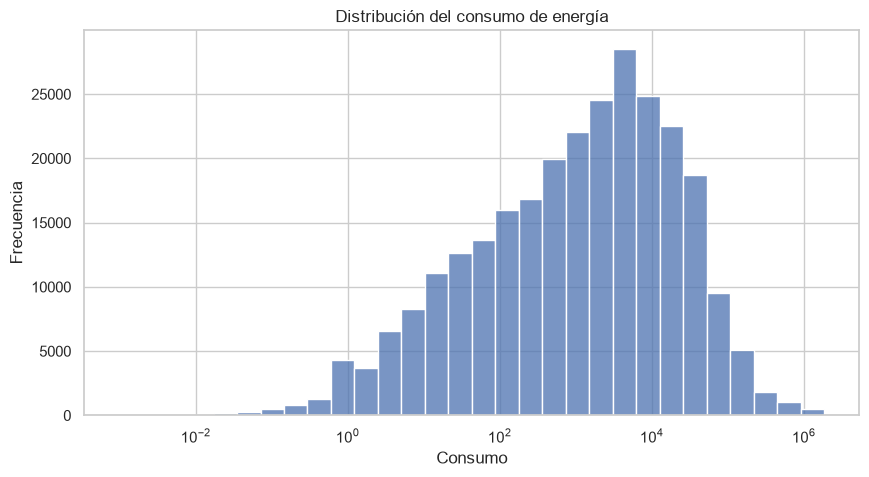

In [6]:
# Histograma de Consumo:
# bins=30 divide los valores en 30 intervalos.
# log_scale=True usa escala logarítmica para visualizar mejor una distribución muy asimétrica.
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_hist,
    x='Consumo',
    bins=30,
    log_scale=True
)

plt.title('Distribución del consumo de energía')
plt.xlabel('Consumo')
plt.ylabel('Frecuencia')
plt.show()


### Conclusiones del gráfico - Distribución del consumo

- La mayor parte de los registros se concentra en valores de consumo relativamente bajos.
- La distribución es asimétrica y contiene valores extremos.
- La escala logarítmica permite visualizar mejor observaciones de magnitudes muy diferentes.

**Hallazgo:** El consumo no se distribuye de forma uniforme; existen muchas observaciones pequeñas y una cantidad menor de registros con consumos muy altos.


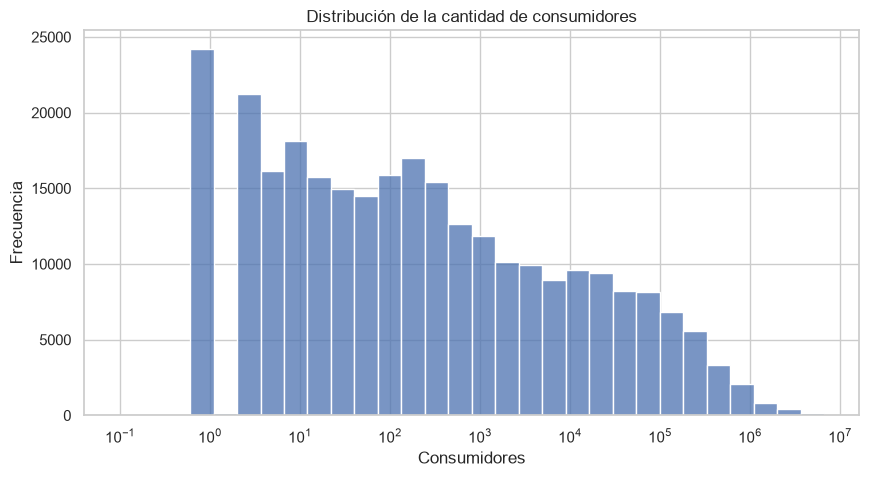

In [7]:
# Histograma de Consumidores con la misma lógica:
# bins=30 controla el nivel de detalle y log_scale=True reduce el efecto visual de valores extremos.
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_hist,
    x='Consumidores',
    bins=30,
    log_scale=True
)

plt.title('Distribución de la cantidad de consumidores')
plt.xlabel('Consumidores')
plt.ylabel('Frecuencia')
plt.show()


### Conclusiones del gráfico - Distribución de consumidores

- La mayor parte de los registros contiene cantidades relativamente bajas de consumidores.
- También se observa una distribución asimétrica con valores extremos.
- La escala logarítmica facilita la lectura de los valores menos frecuentes y de mayor magnitud.

**Hallazgo:** La cantidad de consumidores presenta una fuerte concentración en valores bajos y una cola hacia valores altos.


## 4. Distribución segmentada por tipo de consumidor

Ahora dejamos de observar el consumo de forma global y lo separamos según `TipoConsumidor`.

El boxplot permite comparar la distribución, mediana, dispersión y valores extremos entre grupos.

**Para la defensa:** segmentar sirve para comprobar si una variable se comporta igual en todos los grupos o si existen diferencias entre categorías.


TipoConsumidor
Cativo    251992
Livre      33507
Name: count, dtype: int64


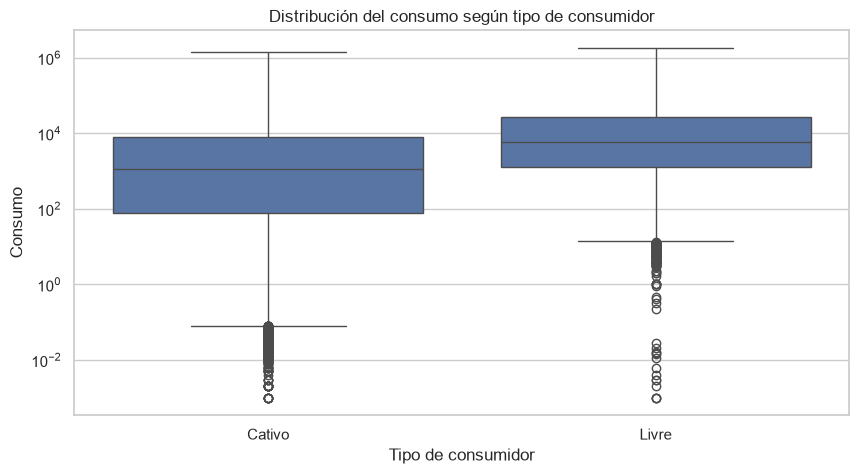

In [8]:
# value_counts() permite conocer cuántos registros existen por tipo de consumidor.
print(df_energia['TipoConsumidor'].value_counts())

# El boxplot compara la distribución del Consumo entre categorías.
# x define la categoría, y la variable numérica y log_scale=True facilita visualizar escalas muy diferentes.
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_hist,
    x='TipoConsumidor',
    y='Consumo',
    log_scale=True
)

plt.title('Distribución del consumo según tipo de consumidor')
plt.xlabel('Tipo de consumidor')
plt.ylabel('Consumo')
plt.show()


### Conclusiones del gráfico - Boxplot por tipo de consumidor

- La línea central de cada caja representa la mediana.
- La caja contiene aproximadamente el 50 % central de los datos.
- Los bigotes muestran el rango habitual y los puntos alejados pueden representar valores atípicos.
- La comparación permite observar diferencias entre `Cativo` y `Livre`.

**Hallazgo:** Los tipos de consumidor presentan distribuciones distintas y una alta dispersión en los valores de consumo.

**Importante:** Un valor atípico no es automáticamente un error; puede representar una observación válida del dataset.


## 5. Relación y correlación entre variables numéricas

Analizamos si `Consumidores` y `Consumo` se mueven conjuntamente.

El **scatterplot** muestra la forma de la relación; la **matriz de correlación** la resume con un coeficiente entre -1 y 1.



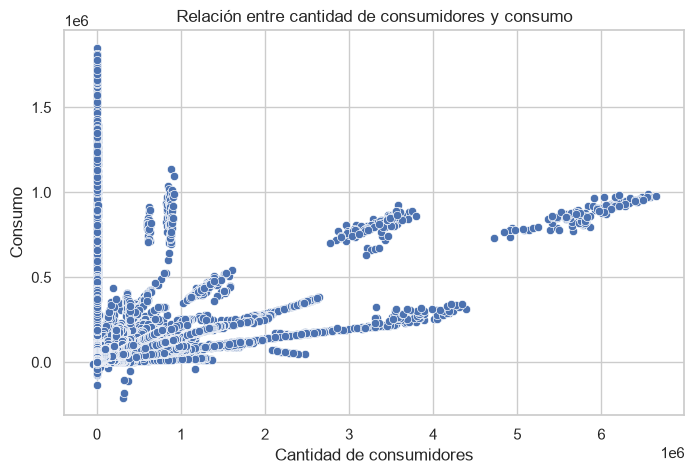

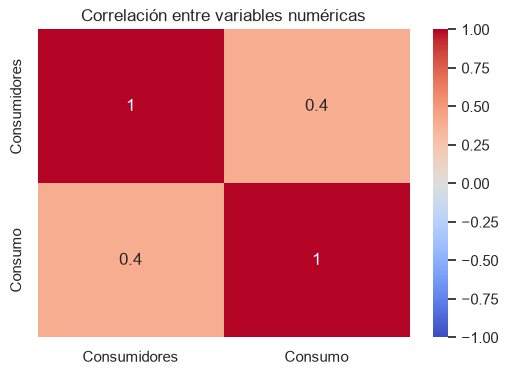

In [9]:
# Seleccionamos las dos variables numéricas principales.
# dropna() elimina solo las filas incompletas necesarias para este análisis de relación.
df_corr = df_hist[['Consumidores', 'Consumo']].dropna()

# scatterplot muestra cada observación como un punto y permite ver la forma de la relación.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_corr,
    x='Consumidores',
    y='Consumo'
)
plt.title('Relación entre cantidad de consumidores y consumo')
plt.xlabel('Cantidad de consumidores')
plt.ylabel('Consumo')
plt.show()

# corr() calcula la correlación lineal entre las variables.
# annot=True escribe el valor numérico dentro del heatmap.
# vmin=-1 y vmax=1 fijan la escala completa posible de correlación.
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Correlación entre variables numéricas')
plt.show()


### Conclusiones de los gráficos - Relación y correlación

- El scatterplot muestra una gran dispersión entre `Consumidores` y `Consumo`.
- No se observa una relación proporcional perfecta entre ambas variables.
- La matriz de correlación resume numéricamente la intensidad de la relación lineal.

**Hallazgo:** Tener más consumidores no implica necesariamente un aumento proporcional del consumo; otras características del dataset también pueden influir.

**Importante:** Correlación no implica causalidad.


El scatterplot permite detectar dispersión y posibles valores extremos que un único coeficiente no mostraría.

Para completar el análisis multivariado, usamos un **pairplot** sobre una muestra de 2.000 registros. La muestra reduce el costo gráfico sin modificar el dataset original.




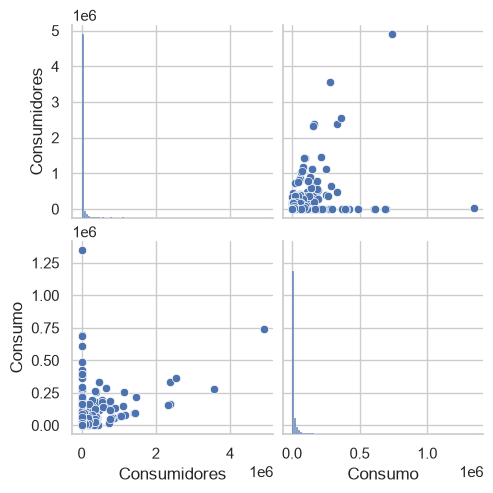

In [10]:
# Tomamos una muestra de 2000 registros para que el pairplot sea más rápido y legible.
# random_state=42 garantiza que se seleccione la misma muestra en cada ejecución.
muestra = df_corr.sample(2000, random_state=42)

# pairplot combina distribuciones individuales y relaciones entre las variables seleccionadas.
sns.pairplot(muestra)
plt.show()


### Conclusiones del gráfico - Pairplot

- Las distribuciones de `Consumidores` y `Consumo` son asimétricas.
- Se observan valores extremos en ambas variables.
- La relación entre ambas presenta bastante dispersión y no forma una línea claramente definida.

**Hallazgo:** El pairplot confirma visualmente que la relación entre cantidad de consumidores y consumo no es estrictamente lineal.

La muestra de 2.000 registros se usa únicamente para visualizar; el dataset original no se modifica.


## 6. Análisis simple: consumo total por UF

Agrupamos los registros por estado (`UF`) y sumamos el consumo para identificar qué estados concentran el mayor consumo total.

**Hallazgo observado:** São Paulo (`SP`) destaca claramente como la UF de mayor consumo.




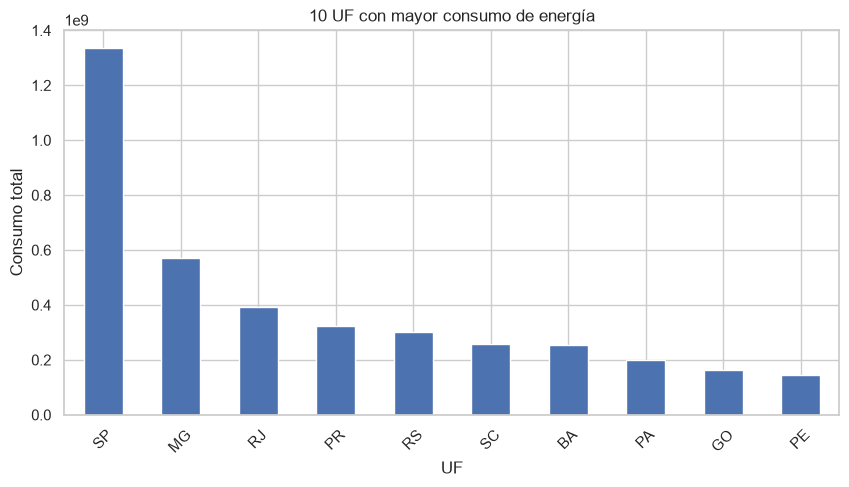

In [11]:
# groupby('UF') agrupa todas las filas del mismo estado.
# sum() calcula el consumo total acumulado de cada UF.
# sort_values() ordena de mayor a menor para identificar los estados de mayor consumo.
consumo_uf = (
    df_hist
    .groupby('UF')['Consumo']
    .sum()
    .sort_values(ascending=False)
)

# head(10) conserva solo las diez UF con mayor consumo para facilitar la comparación.
plt.figure(figsize=(10, 5))
consumo_uf.head(10).plot(kind='bar')
plt.title('10 UF con mayor consumo de energía')
plt.xlabel('UF')
plt.ylabel('Consumo total')
plt.xticks(rotation=45)
plt.show()


### Conclusiones del gráfico - Consumo por UF

- El gráfico compara el consumo total acumulado de las diez UF con mayor consumo.
- São Paulo (`SP`) destaca claramente por encima del resto.
- El uso de `sum()` permite comparar consumo total y no consumo promedio.

**Hallazgo:** `SP` concentra el mayor consumo total entre las UF analizadas.


## 7. Serie temporal: evolución mensual del consumo

Como existen muchos registros para cada mes, primero agregamos todos los consumos mensuales con `resample('ME').sum()`.

Así respondemos a la pregunta: **¿cómo cambió el consumo total de energía entre 2014 y 2023?**

**Hallazgo observado:** existe una tendencia general creciente, una caída muy marcada alrededor de 2020 y una recuperación posterior que alcanza los valores más altos hacia 2023.

No atribuimos una causa a la caída únicamente a partir del gráfico; para hacerlo sería necesario incorporar evidencia externa.




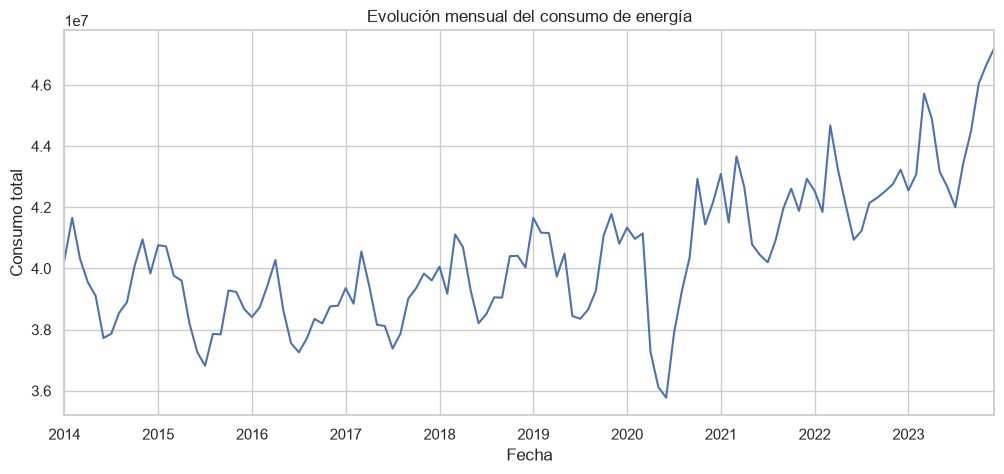

In [12]:
# resample('ME') agrupa los registros por mes usando el final de cada mes como referencia.
# sum() se utiliza porque queremos conocer el consumo TOTAL de cada mes.
df_mensual = df_energia['Consumo'].resample('ME').sum()

# El gráfico de línea permite observar tendencias y cambios a lo largo del tiempo.
plt.figure(figsize=(12, 5))
df_mensual.plot()
plt.title('Evolución mensual del consumo de energía')
plt.xlabel('Fecha')
plt.ylabel('Consumo total')
plt.show()


### Conclusiones del gráfico - Evolución mensual del consumo

- La línea representa el consumo total agregado de cada mes.
- Se observan fluctuaciones durante todo el período.
- Existe una tendencia general creciente.
- Se aprecia una caída marcada alrededor de 2020.
- Después se observa una recuperación hasta alcanzar los valores más altos hacia 2023.

**Hallazgo:** El consumo energético muestra crecimiento general a largo plazo, interrumpido por una caída excepcional alrededor de 2020.

**Importante:** El gráfico permite identificar la caída, pero no demuestra cuál fue su causa.


## 8. Análisis combinado: UF y tipo de consumidor

Como último paso cruzamos tres elementos: `UF`, `TipoConsumidor` y `Consumo`.

Esto permite pasar de una pregunta simple (“¿qué UF consume más?”) a una más específica:  
**“¿cómo se reparte el consumo entre tipos de consumidor dentro de las UF de mayor consumo?”**




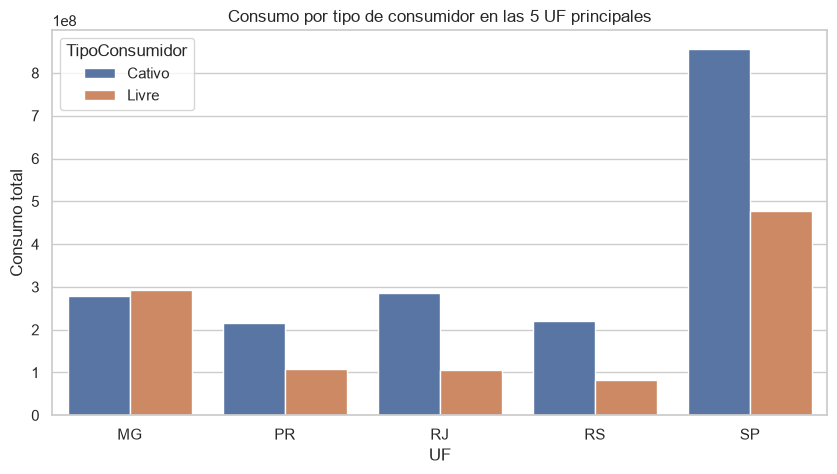

In [13]:
# Seleccionamos las 5 UF con mayor consumo total obtenidas en el análisis anterior.
top_ufs = consumo_uf.head(5).index

# isin(top_ufs) filtra únicamente esas UF.
# Luego agrupamos por UF y TipoConsumidor para comparar cómo se compone el consumo dentro de cada estado.
consumo_tipo_uf = (
    df_hist[df_hist['UF'].isin(top_ufs)]
    .groupby(['UF', 'TipoConsumidor'], as_index=False)['Consumo']
    .sum()
)

# hue='TipoConsumidor' separa visualmente las barras de cada categoría dentro de la misma UF.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=consumo_tipo_uf,
    x='UF',
    y='Consumo',
    hue='TipoConsumidor'
)

plt.title('Consumo por tipo de consumidor en las 5 UF principales')
plt.xlabel('UF')
plt.ylabel('Consumo total')
plt.show()


### Conclusiones del gráfico - Consumo por tipo de consumidor en las UF principales

- São Paulo presenta el mayor consumo entre las cinco UF analizadas.
- En `SP`, `PR`, `RJ` y `RS` predomina el consumo `Cativo`.
- En `MG` los dos grupos están más equilibrados y `Livre` aparece ligeramente por encima.
- Este gráfico permite observar no solo qué UF consume más, sino también cómo se compone ese consumo.

**Hallazgo:** La composición del consumo varía según la UF, aunque `Cativo` domina en la mayoría de los estados principales.


## 9. Conclusiones

El análisis permitió avanzar desde la descripción básica de los datos hasta comparaciones segmentadas y temporales.

Los principales hallazgos son:

- Las variables `Consumo` y `Consumidores` presentan distribuciones muy asimétricas y valores extremos.
- Existen dos tipos principales de consumidor: **Cativo** y **Livre**.
- La relación entre cantidad de consumidores y consumo presenta una dispersión importante, por lo que no debe interpretarse únicamente como una relación proporcional directa.
- **SP** concentra el mayor consumo total entre las UF analizadas.
- La serie temporal muestra crecimiento general entre 2014 y 2023, con una caída excepcional alrededor de 2020 y recuperación posterior.
- El análisis final permite comparar cómo se distribuye el consumo entre tipos de consumidor dentro de las UF con mayor consumo.

